In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('gurgaon_properties_cleaned_v2.csv').drop_duplicates()

In [3]:
df.head()

,property_name,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,2 BHK Flat in Sector 85 Gurgaon,flat,ss the leaf,sector 85,1.07,6524.0,1640.0,Super Built up area 1640(152.36 sq.m.),2,2,...,1640.0,NaN,NaN,0,0,0,1,0,0,67
1,3 BHK Flat in Sector 113 Gurgaon,flat,la vida by tata housing,sector 113,2.78,11346.0,2450.0,Super Built up area 2690(249.91 sq.m.)Built Up...,3,3,...,2690.0,2599.0,2450.0,1,1,0,0,0,0,174
2,3 BHK Flat in Sector 76 Gurgaon,flat,whiteland the aspen,sector 76,3.50,11917.0,2937.0,Built Up area: 2937 (272.86 sq.m.)Carpet area:...,3,4,...,NaN,2937.0,1762.0,0,0,0,0,0,0,0
3,3 BHK Flat in Sector 43 Gurgaon,flat,sanskriti apartments,sector 43,2.50,13513.0,1850.0,Super Built up area 1850(171.87 sq.m.),3,2,...,1850.0,NaN,NaN,1,0,0,0,0,0,0
4,3 BHK Flat in Sector 69 Gurgaon,flat,tulip violet,sector 69,1.42,8998.0,1578.0,Super Built up area 1578(146.6 sq.m.),3,3,...,1578.0,NaN,NaN,0,0,0,1,0,2,94


In [4]:
df.shape

(3799, 27)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3799 entries, 0 to 3802
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   property_name        3799 non-null   object 
 1   property_type        3799 non-null   object 
 2   society              3798 non-null   object 
 3   sector               3799 non-null   object 
 4   price                3781 non-null   float64
 5   price_per_sqft       3781 non-null   float64
 6   area                 3781 non-null   float64
 7   areaWithType         3799 non-null   object 
 8   bedRoom              3799 non-null   int64  
 9   bathroom             3799 non-null   int64  
 10  balcony              3799 non-null   object 
 11  address              3790 non-null   object 
 12  floorNum             3780 non-null   float64
 13  facing               2697 non-null   object 
 14  agePossession        3799 non-null   object 
 15  description          3799 non-null   object

In [6]:
df.isnull().sum()

property_name             0
property_type             0
society                   1
sector                    0
price                    18
price_per_sqft           18
area                     18
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
address                   9
floorNum                 19
facing                 1102
agePossession             0
description               0
rating                  337
super_built_up_area    1885
built_up_area          2068
carpet_area            1857
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
dtype: int64

C:\Users\hp\AppData\Local\Temp\ipykernel_3988\2797181776.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price'])


<Axes: xlabel='price', ylabel='Density'>

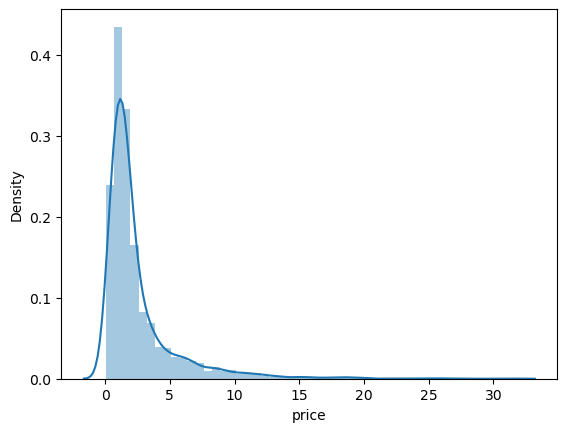

In [7]:
# outliers on the basis of price column
sns.distplot(df['price'])

<Axes: xlabel='price'>

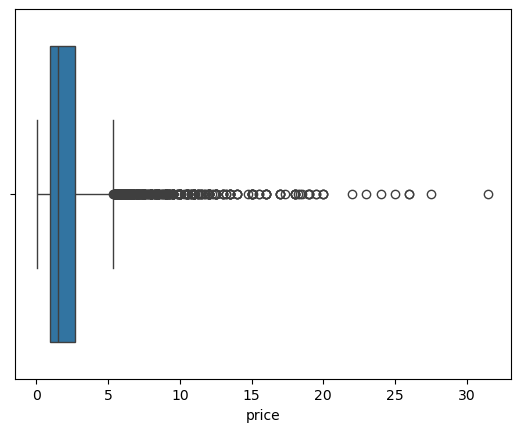

In [8]:
sns.boxplot(x=df['price'])

In [9]:
# Calculate the IQR for the 'price' column
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]

# Displaying the number of outliers and some statistics
num_outliers = outliers.shape[0]
outliers_price_stats = outliers['price'].describe()

num_outliers, outliers_price_stats

(432,
 count    432.000000
 mean       9.196157
 std        4.061291
 min        5.350000
 25%        6.400000
 50%        8.000000
 75%       10.607500
 max       31.500000
 Name: price, dtype: float64)

In [10]:
outliers.sort_values('price',ascending=False).head(20)

,property_name,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
3554,7 Bedroom House for sale in DLF Phase 1,house,arjun marg/ sector- 26 phase- 1/ golf course road,sector 26,31.50,35000.0,9000.0,Plot area 1000(836.13 sq.m.),7,9,...,NaN,9000.0,NaN,1,1,1,1,0,1,74
1357,6 Bedroom House for sale in Sushant Lok Phase 1,house,independent,sector 43,27.50,24366.0,11286.0,Plot area 1254(1048.5 sq.m.),6,7,...,NaN,11286.0,NaN,1,1,0,1,1,2,42
1036,6 Bedroom House for sale in DLF Phase 1,house,dlf city plots,sector 26,26.00,57206.0,4545.0,Plot area 505(422.24 sq.m.),6,7,...,NaN,4545.0,NaN,1,1,0,1,1,2,138
3484,16 Bedroom House for sale in DLF Phase 1,house,independent,sector 26,26.00,82540.0,3150.0,Plot area 402(336.12 sq.m.)Built Up area: 400 ...,16,16,...,NaN,400.0,350.0,1,1,1,1,0,2,72
1826,4 Bedroom House for sale in Sector 54 Gurgaon,house,suncity township,sector 54,25.00,31111.0,8036.0,Plot area 1000(836.13 sq.m.),4,4,...,NaN,1000.0,NaN,1,1,1,1,0,0,0
540,5 Bedroom House for sale in Sector 54 Gurgaon,house,emaar the palm springs,sector 54,24.00,600000.0,400.0,Plot area 400(37.16 sq.m.),5,5,...,NaN,400.0,NaN,1,1,0,1,0,2,122
1566,4 Bedroom House for sale in DLF Phase 1,house,independent,sector 26,23.00,25556.0,9000.0,Plot area 1000(836.13 sq.m.),4,4,...,NaN,9000.0,NaN,1,1,1,1,0,2,145
713,5 Bedroom House for sale in Sector 48 Gurgaon,house,vipul tatvam villa,sector 48,22.00,26667.0,8250.0,Plot area 1000(836.13 sq.m.),5,6,...,NaN,1000.0,NaN,0,1,0,0,0,0,54
884,16 Bedroom House for sale in DLF Phase 1,house,dlf city plots,sector 26,20.00,44265.0,4518.0,Plot area 502(419.74 sq.m.),16,20,...,NaN,4518.0,NaN,1,1,1,1,0,2,153
3140,5 Bedroom House for sale in DLF Phase 1,house,independent,sector 26,20.00,44444.0,4500.0,Plot area 500(418.06 sq.m.),5,7,...,NaN,4500.0,NaN,0,1,0,1,0,1,97


In [11]:
# on the basis of price col we can say that there are some genuine outliers but there are some data erros as well

# Price_per_sqft

C:\Users\hp\AppData\Local\Temp\ipykernel_3988\2186227091.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price_per_sqft'])


<Axes: xlabel='price_per_sqft', ylabel='Density'>

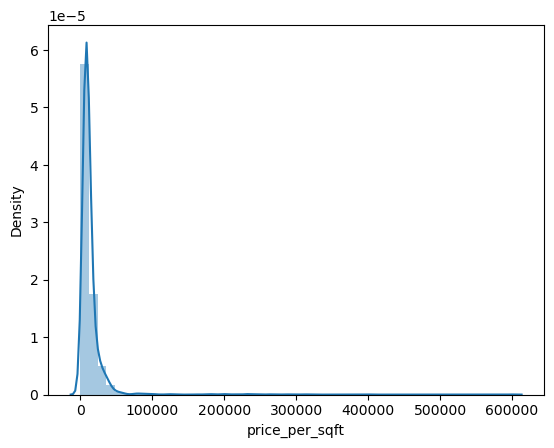

In [12]:
sns.distplot(df['price_per_sqft'])

<Axes: xlabel='price_per_sqft'>

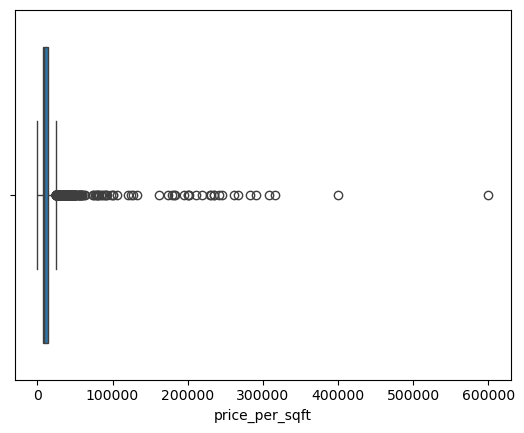

In [13]:
sns.boxplot(x=df['price_per_sqft'])

In [15]:
# Calculate the IQR for the 'price' column
Q1 = df['price_per_sqft'].quantile(0.25)
Q3 = df['price_per_sqft'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers_sqft = df[(df['price_per_sqft'] < lower_bound) | (df['price_per_sqft'] > upper_bound)]

# Displaying the number of outliers and some statistics
num_outliers = outliers_sqft.shape[0]
outliers_sqft_stats = outliers_sqft['price_per_sqft'].describe()

num_outliers, outliers_sqft_stats


(369,
 count       369.000000
 mean      51963.972900
 std       60615.758476
 min       24170.000000
 25%       27778.000000
 50%       33333.000000
 75%       41762.000000
 max      600000.000000
 Name: price_per_sqft, dtype: float64)

In [16]:
outliers_sqft['area'] = outliers_sqft['area'].apply(lambda x:x*9 if x<1000 else x)

C:\Users\hp\AppData\Local\Temp\ipykernel_3988\205471443.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_sqft['area'] = outliers_sqft['area'].apply(lambda x:x*9 if x<1000 else x)


In [17]:
outliers_sqft['price_per_sqft'] = round((outliers_sqft['price']*10000000)/outliers_sqft['area'])

C:\Users\hp\AppData\Local\Temp\ipykernel_3988\3686006548.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_sqft['price_per_sqft'] = round((outliers_sqft['price']*10000000)/outliers_sqft['area'])


In [18]:
outliers_sqft['price_per_sqft'].describe()

count      369.000000
mean     29133.688347
std      12280.403274
min       2689.000000
25%      25000.000000
50%      29545.000000
75%      35484.000000
max      82540.000000
Name: price_per_sqft, dtype: float64

In [19]:
df.update(outliers_sqft)

C:\Users\hp\AppData\Local\Temp\ipykernel_3988\2186227091.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price_per_sqft'])


<Axes: xlabel='price_per_sqft', ylabel='Density'>

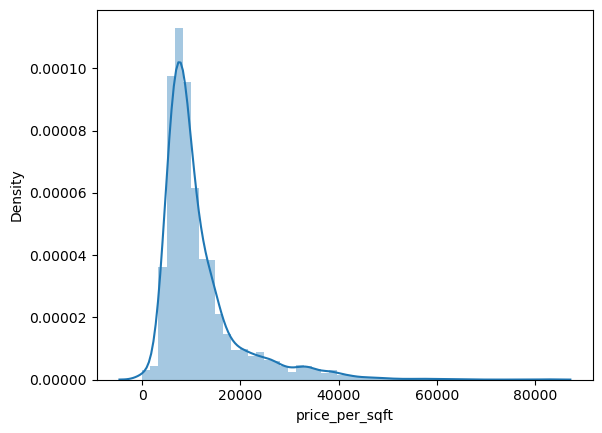

In [20]:
sns.distplot(df['price_per_sqft'])

<Axes: xlabel='price_per_sqft'>

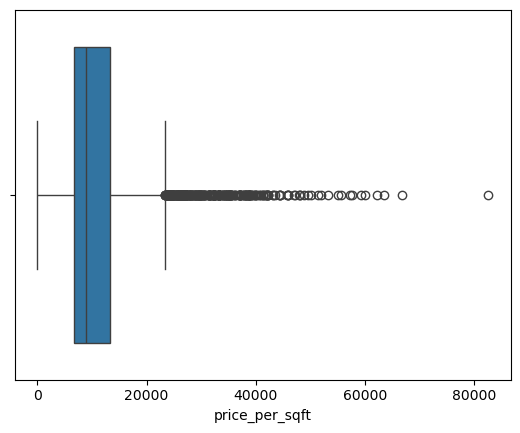

In [22]:
sns.boxplot(x=df['price_per_sqft'])

In [23]:
df[df['price_per_sqft']>50000]

,property_name,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
128,4 Bedroom House for sale in Sector 54 Gurgaon,house,emaar the palm springs,sector 54,14.00,62222.0,2250.0,Plot area 250(209.03 sq.m.),4,5,...,NaN,2250.0,NaN,1,1,0,0,0,2,160
473,2 Bedroom House for sale in Sector 31 Gurgaon,house,project housing board colony,sector 31,8.00,63492.0,1260.0,Built Up area: 140 (117.06 sq.m.),2,1,...,NaN,140.0,NaN,0,0,0,0,0,0,0
540,5 Bedroom House for sale in Sector 54 Gurgaon,house,emaar the palm springs,sector 54,24.00,66667.0,3600.0,Plot area 400(37.16 sq.m.),5,5,...,NaN,400.0,NaN,1,1,0,1,0,2,122
900,16 Bedroom House for sale in DLF Phase 1,house,independent,sector 26,14.75,51864.0,2844.0,Plot area 316(264.22 sq.m.),16,20,...,NaN,2844.0,NaN,1,1,1,1,0,2,153
1036,6 Bedroom House for sale in DLF Phase 1,house,dlf city plots,sector 26,26.00,57206.0,4545.0,Plot area 505(422.24 sq.m.),6,7,...,NaN,4545.0,NaN,1,1,0,1,1,2,138
1241,16 Bedroom House for sale in DLF Phase 2,house,independent,sector 25,16.00,59259.0,2700.0,Plot area 350(292.64 sq.m.)Built Up area: 325 ...,16,16,...,NaN,325.0,300.0,1,1,1,1,0,2,72
1364,4 Bedroom House for sale in Nirvana Country,house,unitech escape,sector 50,10.80,60000.0,1800.0,Plot area 290(242.48 sq.m.)Built Up area: 250 ...,4,4,...,NaN,250.0,200.0,1,1,1,1,0,2,103
1830,12 Bedroom House for sale in Malibu Town,house,malibu towne,sector 47,8.50,53125.0,1600.0,Built Up area: 1600 (148.64 sq.m.),12,12,...,NaN,1600.0,NaN,0,0,0,0,0,2,99
1903,3 BHK Flat in Sector 70 Gurgaon,flat,unitech vistas,sector 70,9.00,57508.0,1565.0,Built Up area: 1565 (145.39 sq.m.),3,3,...,NaN,1565.0,NaN,0,0,0,0,0,0,0
2372,4 Bedroom House for sale in Sector 66 Gurgaon,house,emaar mgf marbella,sector 66,18.00,55556.0,3240.0,Plot area 360(301.01 sq.m.),4,4,...,NaN,3240.0,NaN,1,1,0,1,0,1,75


In [24]:
df = df[df['price_per_sqft'] <= 50000]

<Axes: xlabel='price_per_sqft'>

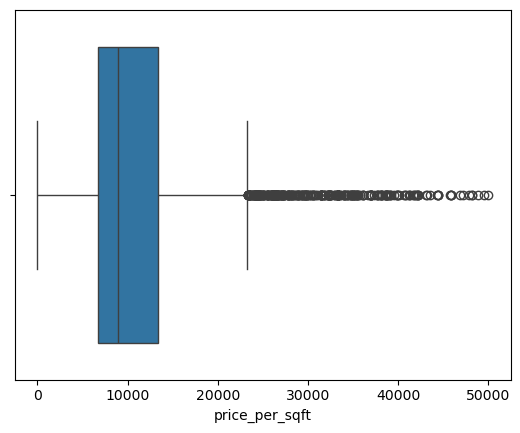

In [25]:
sns.boxplot(x=df['price_per_sqft'])

# Area

C:\Users\hp\AppData\Local\Temp\ipykernel_3988\91062565.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['area'])


<Axes: xlabel='area', ylabel='Density'>

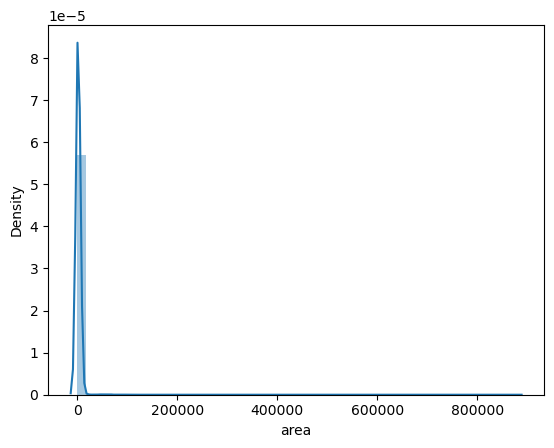

In [26]:
sns.distplot(df['area'])

<Axes: xlabel='area'>

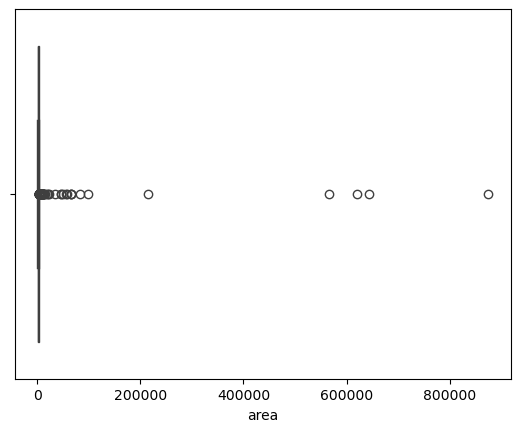

In [27]:
sns.boxplot(x=df['area'])

In [28]:
df['area'].describe()

count      3768.000000
mean       2908.278397
std       22834.361801
min         145.000000
25%        1257.750000
50%        1745.000000
75%        2340.000000
max      875000.000000
Name: area, dtype: float64

In [29]:
df[df['area'] > 100000]

,property_name,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1791,6 Bedroom House for sale in Sector 50 Gurgaon,house,independent,sector 50,5.00,232.0,215517.0,Plot area 2(1011.71 sq.m.),6,5,...,NaN,2.0,NaN,1,1,0,1,1,2,0
1979,2 BHK Flat in Sohna,flat,hcbs sports ville,sohna road,0.35,4.0,875000.0,Built Up area: 737147 (68483.2 sq.m.),2,2,...,NaN,737147.0,NaN,0,0,0,0,0,1,44
2520,2 BHK Flat in Sector 95A Gurgaon,flat,signature the roselia,sector 95,0.45,7.0,642857.0,Carpet area: 569243 (52884.41 sq.m.),2,2,...,NaN,NaN,569243.0,0,0,0,0,0,0,76
2877,2 BHK Flat in Sector 95 Gurgaon,flat,ramsons kshitij,sector 95,0.31,5.0,620000.0,Carpet area: 607936 (56479.1 sq.m.),2,2,...,NaN,NaN,607936.0,1,0,0,0,1,0,65
3787,2 BHK Flat in Sector 107 Gurgaon,flat,signature global solera 2,sector 107,0.51,9.0,566667.0,Carpet area: 514396 (47788.95 sq.m.),2,2,...,NaN,NaN,514396.0,0,0,0,0,0,0,44


In [30]:
df = df[df['area'] < 100000]

C:\Users\hp\AppData\Local\Temp\ipykernel_3988\91062565.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['area'])


<Axes: xlabel='area', ylabel='Density'>

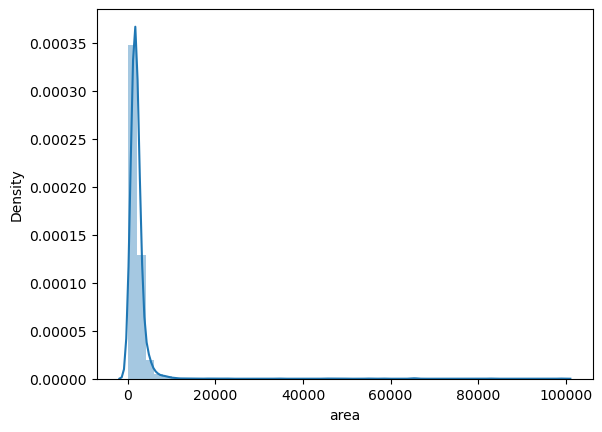

In [31]:
sns.distplot(df['area'])

<Axes: xlabel='area'>

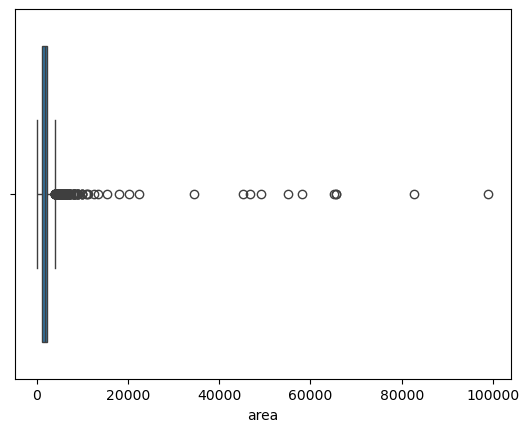

In [32]:
sns.boxplot(x=df['area'])

In [33]:
df[df['area'] > 10000].sort_values('area',ascending=False)

,property_name,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2258,6 Bedroom House for sale in DLF Phase 1,house,independent,sector 26,18.40,1859.0,98978.0,Plot area 502(419.74 sq.m.)Carpet area: 11000 ...,6,8,...,NaN,NaN,11000.00,0,1,1,1,0,2,60
603,10 Bedroom House for sale in Prem Nagar,house,ganpati heights apartment,sector 13,1.25,151.0,82781.0,Plot area 115(7692.86 sq.m.),10,6,...,NaN,115.0,NaN,0,0,0,0,1,0,7
1011,3 BHK Flat in Sector 95 Gurgaon,flat,rof ananda,sector 95,0.38,58.0,65517.0,Carpet area: 64412 (5984.07 sq.m.),3,2,...,NaN,NaN,64412.00,0,0,0,0,0,0,51
1144,2 BHK Flat in Sector 95 Gurgaon,flat,rof ananda,sector 95,0.38,58.0,65517.0,Carpet area: 64529 (5994.94 sq.m.),2,2,...,NaN,NaN,64529.00,1,0,0,0,0,0,15
1684,10 Bedroom House for sale in DLF Phase 4,house,dlf city plot phase 4,sector 28,13.00,1992.0,65261.0,Carpet area: 7250 (6061.92 sq.m.),10,10,...,NaN,NaN,7250.00,0,0,0,0,0,0,0
299,2 BHK Flat in Sector 86 Gurgaon,flat,pyramid elite,sector 86,0.46,79.0,58228.0,Carpet area: 58141 (5401.48 sq.m.),2,2,...,NaN,NaN,58141.00,0,0,0,0,0,0,15
2629,2 BHK Flat in Sector 95 Gurgaon,flat,rof ananda,sector 95,0.33,60.0,55000.0,Carpet area: 54917 (5101.96 sq.m.),2,2,...,NaN,NaN,54917.00,0,0,0,0,0,0,37
688,1 BHK Flat in Sohna,flat,signature the serenas,sohna road,0.28,57.0,49123.0,Carpet area: 48811 (4534.69 sq.m.),1,1,...,NaN,NaN,48811.00,1,0,0,0,0,0,37
7,9 Bedroom House for sale in DLF Phase 2,house,independent,sector 25,7.30,1560.0,46795.0,Plot area 215(179.77 sq.m.)Built Up area: 5800...,9,9,...,NaN,5800.0,5200.00,0,1,1,0,0,2,109
972,2 BHK Flat in Sector 95 Gurgaon,flat,ramsons kshitij,sector 95,0.24,53.0,45283.0,Carpet area: 45966 (4270.38 sq.m.),2,2,...,NaN,NaN,45966.00,0,0,0,0,1,0,33


In [35]:
df=df[df['area'] <= 10000]

In [36]:
df.shape

(3743, 27)

C:\Users\hp\AppData\Local\Temp\ipykernel_3988\91062565.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['area'])


<Axes: xlabel='area', ylabel='Density'>

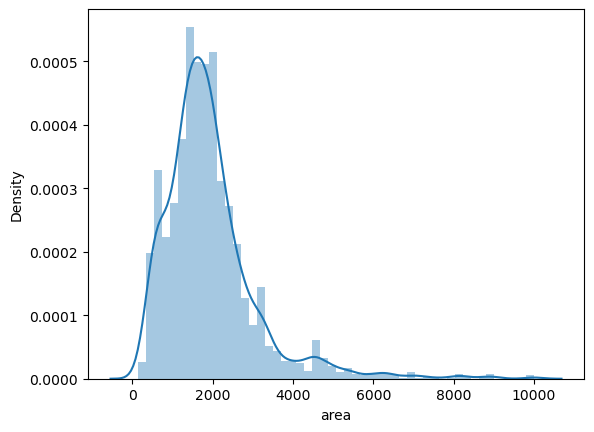

In [37]:
sns.distplot(df['area'])

<Axes: ylabel='area'>

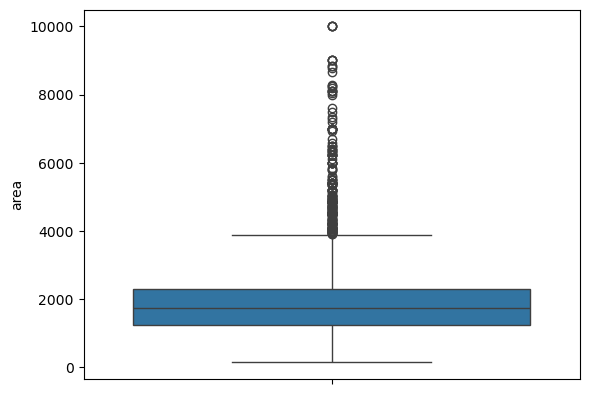

In [38]:
sns.boxplot(df['area'])

In [40]:
df['area'].describe()

count     3743.000000
mean      1933.172589
std       1183.147000
min        145.000000
25%       1250.000000
50%       1741.000000
75%       2307.500000
max      10000.000000
Name: area, dtype: float64

# Bedroom

C:\Users\hp\AppData\Local\Temp\ipykernel_3988\1691983684.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bedRoom'])


<Axes: xlabel='bedRoom', ylabel='Density'>

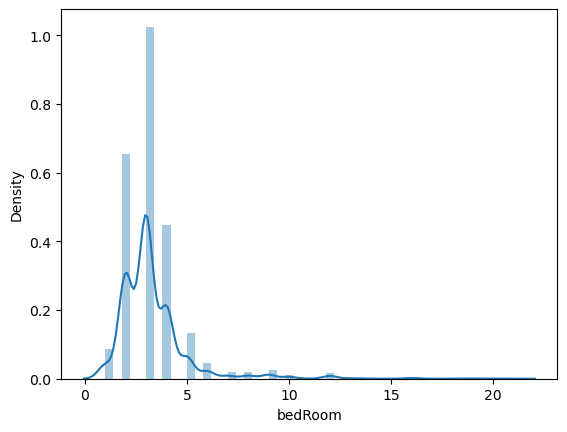

In [41]:
sns.distplot(df['bedRoom'])

<Axes: xlabel='bedRoom'>

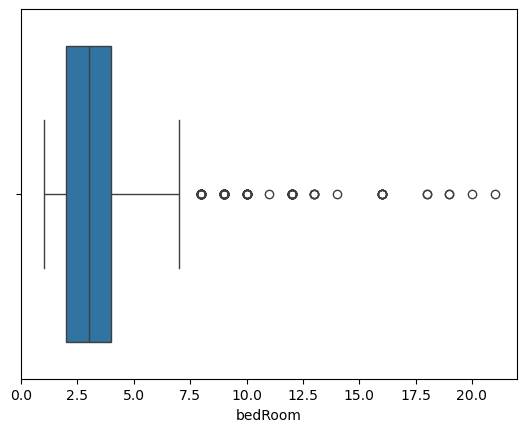

In [42]:
sns.boxplot(x=df['bedRoom'])

In [43]:
df['bedRoom'].describe()

count    3743.000000
mean        3.303767
std         1.799966
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        21.000000
Name: bedRoom, dtype: float64

In [44]:
df[df['bedRoom'] > 10].sort_values('bedRoom',ascending=False)

,property_name,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2814,21 Bedroom House for sale in Sector 54 Gurgaon,house,independent,sector 54,5.00,43066.0,1161.0,Plot area 129(107.86 sq.m.),21,21,...,NaN,1161.0,NaN,0,1,0,0,0,1,49
1845,20 Bedroom House for sale in Sushant Lok Phase 1,house,independent,sector 43,4.50,39062.0,1152.0,Plot area 128(107.02 sq.m.),20,20,...,NaN,1152.0,NaN,0,1,0,0,0,1,22
1526,19 Bedroom House for sale in Sector 17A Gurgaon,house,independent,sector 17a,3.87,5160.0,7500.0,Plot area 1623(150.78 sq.m.)Built Up area: 750...,19,17,...,NaN,7500.0,NaN,1,0,1,0,0,0,68
2318,19 Bedroom House for sale in Sector 17A Gurgaon,house,independent,sector 17a,3.93,24214.0,1623.0,Plot area 1623(150.78 sq.m.)Built Up area: 162...,19,17,...,NaN,1622.0,NaN,1,1,1,1,0,0,74
2874,18 Bedroom House for sale in Sector 55 Gurgaon,house,private house,sector 55,7.05,46906.0,1503.0,Plot area 167(139.63 sq.m.),18,18,...,NaN,1503.0,NaN,0,0,0,0,1,1,57
2105,18 Bedroom House for sale in Suncity,house,independent,sector 54,5.50,38194.0,1440.0,Plot area 160(133.78 sq.m.),18,18,...,NaN,1440.0,NaN,0,1,0,0,0,1,70
1889,16 Bedroom House for sale in Shivaji Nagar,house,independent,sector 11,4.50,25000.0,1800.0,Plot area 200(167.23 sq.m.),16,16,...,NaN,1800.0,NaN,0,0,0,0,0,2,20
2882,16 Bedroom House for sale in Sector 40 Gurgaon,house,independent,sector 40,12.00,38986.0,3078.0,Plot area 342(285.96 sq.m.),16,16,...,NaN,3078.0,NaN,1,1,1,1,0,2,0
2778,16 Bedroom House for sale in Sushant Lok Phase 2,house,independent,sector 55,9.19,34037.0,2700.0,Plot area 300(250.84 sq.m.),16,18,...,NaN,2700.0,NaN,0,1,0,1,0,2,49
459,16 Bedroom House for sale in DLF Phase 1,house,luxury dlf city floors,sector 26,20.00,48888.0,4091.0,Plot area 500(418.06 sq.m.),16,16,...,NaN,500.0,NaN,0,1,0,0,0,2,31


In [45]:
df = df[df['bedRoom'] <= 10]

In [46]:
df.shape

(3698, 27)

C:\Users\hp\AppData\Local\Temp\ipykernel_3988\1691983684.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bedRoom'])


<Axes: xlabel='bedRoom', ylabel='Density'>

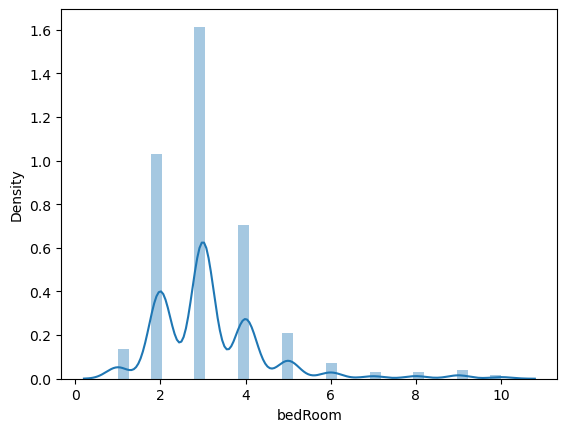

In [48]:
sns.distplot(df['bedRoom'])

<Axes: ylabel='bedRoom'>

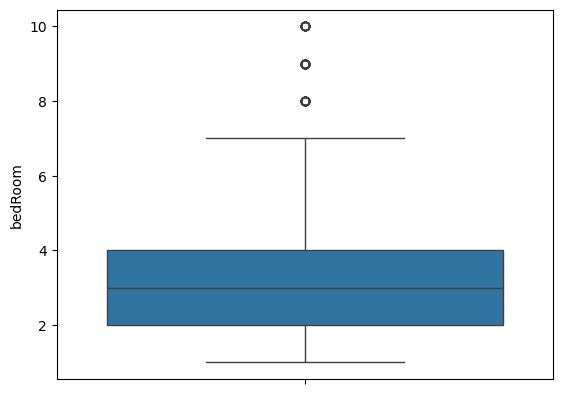

In [49]:
sns.boxplot(df['bedRoom'])

In [50]:
df['bedRoom'].describe()

count    3698.000000
mean        3.177393
std         1.366514
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        10.000000
Name: bedRoom, dtype: float64

# Bathroom

C:\Users\hp\AppData\Local\Temp\ipykernel_3988\2904465235.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bathroom'])


<Axes: xlabel='bathroom', ylabel='Density'>

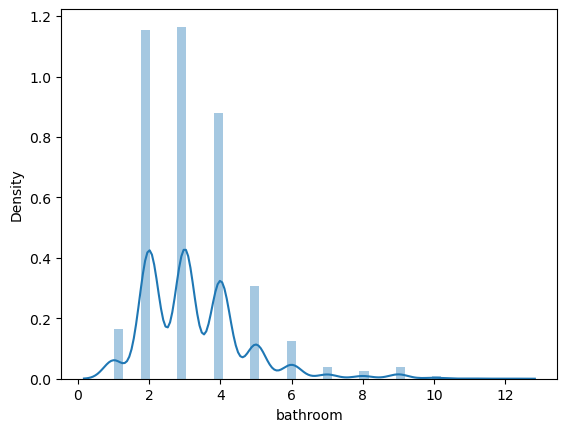

In [51]:
sns.distplot(df['bathroom'])

<Axes: xlabel='bathroom'>

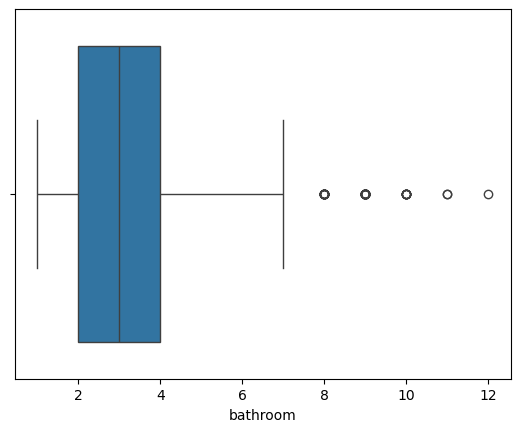

In [52]:
sns.boxplot(x=df['bathroom'])

In [53]:
df[df['bathroom'] > 10].sort_values('bathroom',ascending=False)

,property_name,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
3476,9 Bedroom House for sale in Sector 60 Gurgaon,house,adani brahma samsara,sector 60,18.02,28200.0,6390.0,Built Up area: 6390 (593.65 sq.m.),9,12,...,NaN,6390.0,NaN,0,1,0,0,0,2,146
302,8 Bedroom House for sale in DLF Phase 3,house,independent,sector 24,11.00,28902.0,3806.0,Plot area 3806.45(353.63 sq.m.)Built Up area: ...,8,11,...,NaN,5000.0,NaN,1,1,0,1,1,2,39
1916,10 Bedroom House for sale in Sector 39 Gurgaon,house,independent,sector 39,7.00,10000.0,7000.0,Plot area 350(32.52 sq.m.)Built Up area: 7000 ...,10,11,...,NaN,7000.0,NaN,0,0,0,1,0,2,38


In [54]:
df=df[df['bathroom'] < 10]

In [55]:
df.shape

(3687, 27)

# super built up area

C:\Users\hp\AppData\Local\Temp\ipykernel_3988\4184943455.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['super_built_up_area'])


<Axes: xlabel='super_built_up_area', ylabel='Density'>

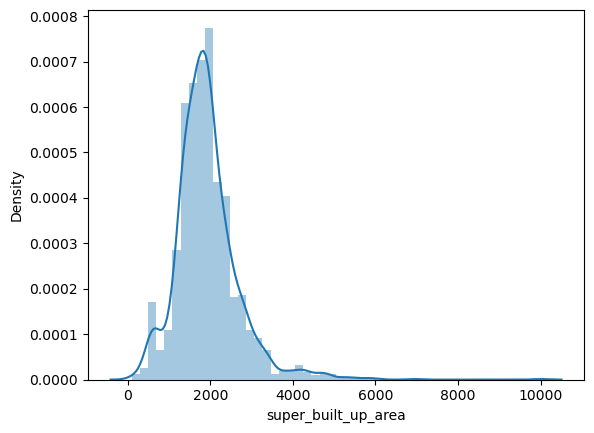

In [56]:
sns.distplot(df['super_built_up_area'])

<Axes: xlabel='super_built_up_area'>

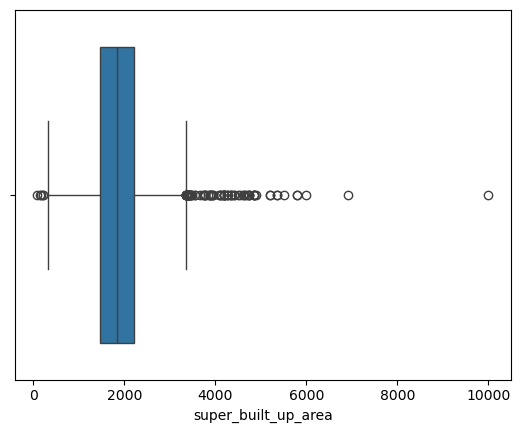

In [57]:
sns.boxplot(x=df['super_built_up_area'])

In [58]:
df['super_built_up_area'].describe()

count     1914.000000
mean      1922.322649
std        766.809367
min         89.000000
25%       1457.000000
50%       1828.000000
75%       2215.000000
max      10000.000000
Name: super_built_up_area, dtype: float64

In [59]:
df[df['super_built_up_area'] > 6000]

,property_name,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2242,4 BHK Flat in Sector 81 Gurgaon,flat,bestech park view grand spa,sector 81,4.7,6786.0,6926.0,Super Built up area 6926(643.45 sq.m.),4,4,...,6926.0,NaN,NaN,0,1,0,0,0,2,140
2281,5 BHK Flat in Gwal Pahari,flat,krrish provence estate,gwal pahari,7.5,7500.0,10000.0,Super Built up area 10000(929.03 sq.m.),5,6,...,10000.0,NaN,NaN,0,1,0,1,1,0,49


# built up area

C:\Users\hp\AppData\Local\Temp\ipykernel_3988\3494228458.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['built_up_area'])


<Axes: xlabel='built_up_area', ylabel='Density'>

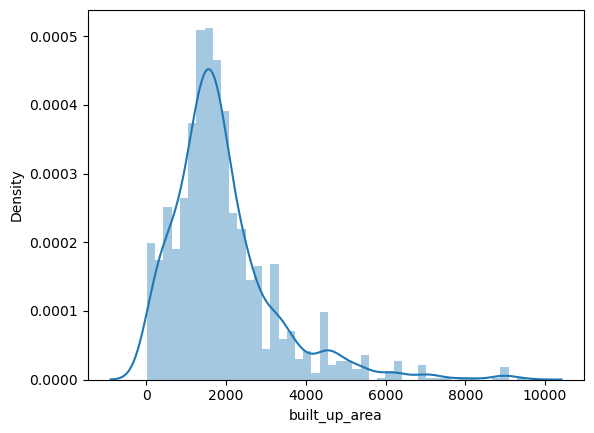

In [60]:
sns.distplot(df['built_up_area'])

<Axes: xlabel='built_up_area'>

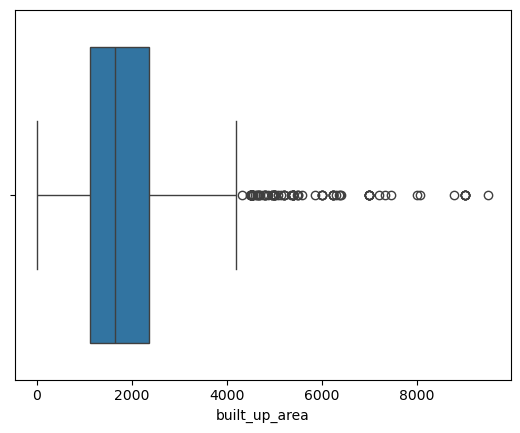

In [61]:
sns.boxplot(x=df['built_up_area'])

In [62]:
df[df['built_up_area'] > 10000]

,property_name,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score


# carpet area

C:\Users\hp\AppData\Local\Temp\ipykernel_3988\3905767603.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['carpet_area'])


<Axes: xlabel='carpet_area', ylabel='Density'>

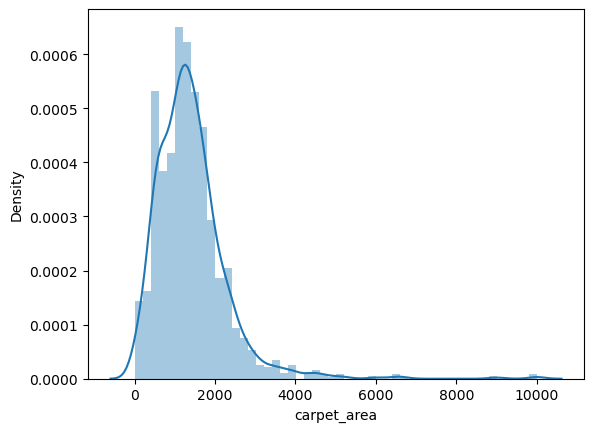

In [63]:
sns.distplot(df['carpet_area'])

<Axes: ylabel='carpet_area'>

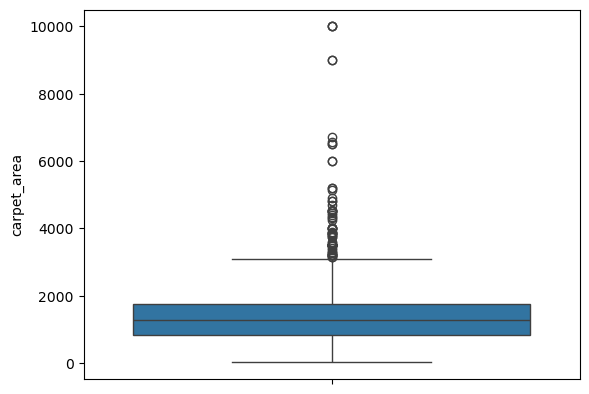

In [64]:
sns.boxplot(df['carpet_area'])

In [65]:
df[df['carpet_area'] > 10000]

,property_name,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score


# Luxury Score

C:\Users\hp\AppData\Local\Temp\ipykernel_3988\3385064764.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['luxury_score'])


<Axes: xlabel='luxury_score', ylabel='Density'>

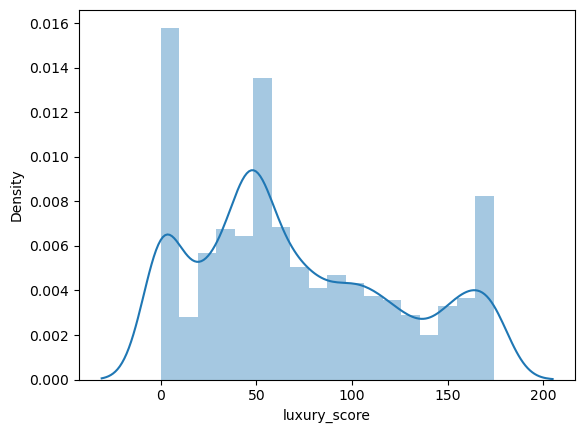

In [66]:
sns.distplot(df['luxury_score'])

<Axes: ylabel='luxury_score'>

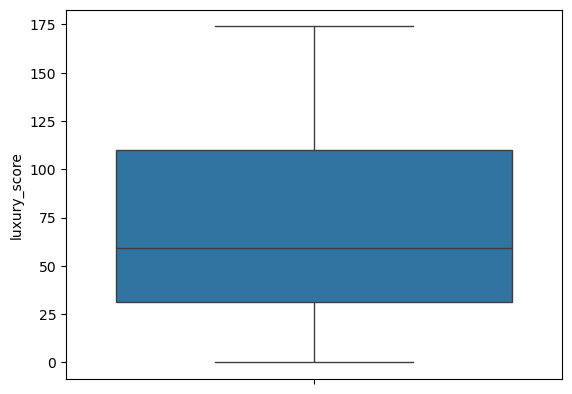

In [67]:
sns.boxplot(df['luxury_score'])

<Axes: ylabel='price_per_sqft'>

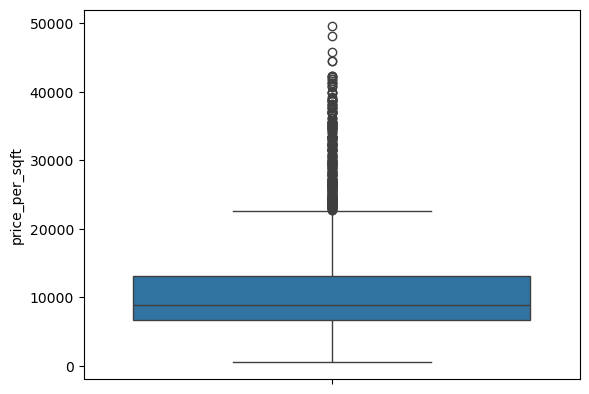

In [68]:
sns.boxplot(df['price_per_sqft'])

In [69]:
df['price_per_sqft'].describe()

count     3687.000000
mean     11180.068077
std       6986.221858
min        544.000000
25%       6735.000000
50%       8882.000000
75%      13101.500000
max      49500.000000
Name: price_per_sqft, dtype: float64

In [70]:
df[df['price_per_sqft'] > 40000]

,property_name,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
186,2 Bedroom House for sale in Rajendra Park,house,independent,sector 105,9.90,49500.0,2000.0,Built Up area: 2000 (185.81 sq.m.)Carpet area:...,2,2,...,NaN,2000.0,1800.0,0,0,0,0,0,0,0
304,4 Bedroom House for sale in Sector 50 Gurgaon,house,ss hibiscus,sector 50,12.50,40850.0,3060.0,Plot area 470(392.98 sq.m.)Built Up area: 410 ...,4,4,...,NaN,410.0,340.0,1,1,0,0,0,1,160
615,4 Bedroom House for sale in Nirvana Country,house,unitech espace,sector 50,7.35,41761.0,1760.0,Plot area 240(200.67 sq.m.),4,4,...,NaN,240.0,NaN,0,1,0,1,0,2,52
619,6 Bedroom House for sale in Sector 50 Gurgaon,house,independent,sector 50,12.50,40611.0,3078.0,Plot area 342(285.96 sq.m.),6,5,...,NaN,3078.0,NaN,1,1,0,1,0,2,23
647,5 Bedroom House for sale in Sushant Lok Phase 1,house,independent,sector 43,9.50,42222.0,2250.0,Plot area 302(252.51 sq.m.)Built Up area: 300 ...,5,5,...,NaN,300.0,250.0,0,1,0,1,0,2,88
1584,4 Bedroom House for sale in DLF Phase 4,house,independent,sector 28,12.00,42194.0,2844.0,Plot area 316(264.22 sq.m.),4,5,...,NaN,2844.0,NaN,0,1,1,1,0,2,60
1871,3 BHK Flat in Sector 54 Gurgaon,flat,dlf the grove,sector 54,5.70,41245.0,1382.0,Built Up area: 1382 (128.39 sq.m.),3,3,...,NaN,1382.0,NaN,0,0,0,0,0,0,46
2210,3 Bedroom House for sale in Sushant Lok Phase 1,house,sushant lok 1 builder floors,sector 43,13.00,48148.0,2700.0,Plot area 300(250.84 sq.m.),3,3,...,NaN,2700.0,NaN,0,0,0,1,0,2,7
2250,4 Bedroom House for sale in DLF Phase 4,house,independent,sector 28,11.75,41315.0,2844.0,Plot area 316(264.22 sq.m.),4,5,...,NaN,2844.0,NaN,1,1,1,0,0,2,54
2326,6 Bedroom House for sale in DLF Phase 2,house,independent,sector 25,13.00,45710.0,2844.0,Plot area 316(264.22 sq.m.),6,8,...,NaN,2844.0,NaN,1,1,1,1,0,1,0


In [71]:
df=df[df['price_per_sqft'] < 40000]

In [72]:
df.shape

(3668, 27)

In [73]:
df['price_per_sqft'].describe()

count     3668.000000
mean     11016.565976
std       6621.059912
min        544.000000
25%       6722.000000
50%       8855.500000
75%      12963.000000
max      39886.000000
Name: price_per_sqft, dtype: float64

In [76]:
x = df[df['price_per_sqft'] <= 20000]
(x['area']/x['bedRoom']).quantile(0.05)

np.float64(257.3)

In [77]:
df[(df['area']/df['bedRoom'])<257]

,property_name,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
9,2 BHK Flat in Sector 99A Gurgaon,flat,conscient habitat,sector 99a,0.27,5599.0,482.0,Carpet area: 484 (44.97 sq.m.),2,2,...,NaN,NaN,484.000000,0,0,0,0,1,0,49
19,3 BHK Flat in Sector 95 Gurgaon,flat,rof ananda,sector 95,0.38,5899.0,644.0,Carpet area: 644.12 (59.84 sq.m.),3,2,...,NaN,NaN,644.111776,0,0,0,1,0,2,66
22,9 Bedroom House for sale in Dharam Colony,house,independent,sector 12,1.00,8230.0,1215.0,Plot area 135(12.54 sq.m.)Built Up area: 3750 ...,9,7,...,NaN,3750.0,NaN,0,0,1,1,0,0,7
24,7 Bedroom House for sale in Ashok Vihar Phase ...,house,ashok vihar phase iii extension,sector 3 phase 3 extension,0.40,8889.0,450.0,Plot area 50(41.81 sq.m.),7,4,...,NaN,450.0,NaN,0,0,0,1,0,0,7
31,5 Bedroom House for sale in Dwarka Expressway ...,house,rattan vihar rajendra park,dwarka expressway,0.85,14166.0,600.0,Plot area 600(55.74 sq.m.),5,5,...,NaN,600.0,NaN,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3733,5 Bedroom House for sale in Rajiv Nagar,house,independent,sector 13,0.90,11464.0,785.0,Plot area 785(72.93 sq.m.),5,4,...,NaN,785.0,NaN,1,1,0,1,1,0,0
3742,2 BHK Flat in Sector 84 Gurgaon,flat,pivotal devaan,sector 84,0.35,7246.0,483.0,Carpet area: 483 (44.87 sq.m.),2,2,...,NaN,NaN,483.000000,0,0,0,0,0,0,37
3760,4 Bedroom House for sale in Laxman Vihar Phase 2,house,independent,sector 4,0.92,15257.0,603.0,Plot area 67(56.02 sq.m.),4,4,...,NaN,603.0,NaN,0,0,0,0,1,0,0
3774,5 Bedroom House for sale in Laxman Vihar Phase 2,house,independent,sector 4,0.50,9259.0,540.0,Plot area 540(50.17 sq.m.),5,3,...,NaN,540.0,NaN,0,0,0,0,0,0,0
